# **RED CONVOLUCIONAL 2**

Sin transfer learning, entrenada manualmente.

In [5]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import defaultdict
import os
import cv2
import csv
import torch
import kagglehub
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# IMPORTA DATOS DE KAGGLE

In [ ]:
# === FRAGMENTO 1 ===
KAGGLE_DATASET_ID = 'pkdarabi/cardetection'
print(f"Descargando dataset: {KAGGLE_DATASET_ID}")
KAGGLE_DOWNLOAD_PATH = kagglehub.dataset_download(KAGGLE_DATASET_ID)
print(f"Dataset descargado en: {KAGGLE_DOWNLOAD_PATH}")

print("\n--- Generando archivos CSV desde los directorios 'labels' ---")
base_data_path = os.path.join(KAGGLE_DOWNLOAD_PATH, "car")
splits_names = ["train", "valid", "test"]
DATA_DIR = './' 

csv_header = ['nombre_archivo', 'clase_indice', 'x_center', 'y_center', 'width', 'height']

for split in splits_names:
    labels_dir = os.path.join(base_data_path, split, "labels")
    
    # Nombre del archivo CSV de salida que se va a crear
    output_csv_file = os.path.join(DATA_DIR, f"../CSVs/labels_{split}.csv")
    
    print(f"Procesando: {labels_dir}")

    if not os.path.exists(labels_dir):
        print(f"  - Advertencia: No se encontró el directorio de etiquetas: {labels_dir}")
        continue

    # Abrir el nuevo archivo CSV en modo escritura
    with open(output_csv_file, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(csv_header) # Escribir la cabecera
        
        # Recorrer cada archivo .txt en el directorio de etiquetas
        for txt_filename in os.listdir(labels_dir):
            if txt_filename.endswith('.txt'):
                
                # Se asume que la imagen tiene el mismo nombre pero con .jpg
                # (o .png, etc., ajustar si es necesario)
                image_filename = txt_filename.replace('.txt', '.jpg')
                txt_filepath = os.path.join(labels_dir, txt_filename)
                
                # Leer el contenido del archivo .txt
                with open(txt_filepath, 'r') as f_txt:
                    for line in f_txt:
                        parts = line.strip().split()
                        if len(parts) == 5:
                            # 'parts' es [clase, x, y, w, h]
                            clase_idx = parts[0]
                            x_center = parts[1]
                            y_center = parts[2]
                            width = parts[3]
                            height = parts[4]
                            
                            # Escribir la fila completa en el CSV
                            writer.writerow([image_filename, clase_idx, x_center, y_center, width, height])

    print(f"  - ¡CSV Creado! -> {output_csv_file}")

IMAGE_SIZE = (416, 416)
BATCH_SIZE = 32

# Normalización ESTANDAR
normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                 std=[0.5, 0.5, 0.5])

# 1. Transformaciones para ENTRENAMIENTO (con aumento de datos)
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),  # Volteo aleatorio
    transforms.RandomRotation(15),           # Rotación aleatoria
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Cambios de color
    transforms.ToTensor(),                   # Convertir a Tensor
    normalize,                               # Normalizar
])

# 2. Transformaciones para VALIDACIÓN y TEST (solo limpiar)
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    normalize,
])

# Esta clase ahora funcionará porque leerá los CSVs que acabamos de crear.
class DataSet(Dataset):
    def __init__(self, archivo_csv, directorio_imagenes, transform=None):
        self.directorio_imagenes = directorio_imagenes
        self.transform = transform
        
        try:
            self.full_labels_df = pd.read_csv(archivo_csv)
        except FileNotFoundError:
            print(f"  - ¡Error! No se encontró el archivo CSV: {archivo_csv}")
            self.full_labels_df = pd.DataFrame(columns=['nombre_archivo'])
            
        self.imagenes_unicas = self.full_labels_df['nombre_archivo'].unique()
        self.labels_grouped = self.full_labels_df.groupby('nombre_archivo')

    def __len__(self):
        return len(self.imagenes_unicas)

    def __getitem__(self, idx):
        image_name = self.imagenes_unicas[idx]
        image_path = os.path.join(self.directorio_imagenes, image_name)
        
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            return torch.zeros(3, IMAGE_SIZE[0], IMAGE_SIZE[1]), torch.tensor(-1) 

        boxes_df = self.labels_grouped.get_group(image_name)
        clase_idx = int(boxes_df['clase_indice'].iloc[0])
        label = torch.tensor(clase_idx, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

Descargando dataset: pkdarabi/cardetection
Dataset descargado en: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5

--- Generando archivos CSV desde los directorios 'labels' ---
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\labels
  - ¡CSV Creado! -> ./../CSVs/labels_train.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\labels
  - ¡CSV Creado! -> ./../CSVs/labels_valid.csv
Procesando: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\labels
  - ¡CSV Creado! -> ./../CSVs/labels_test.csv


In [7]:
# === FRAGMENTO 2 ===
# Preparación de los CSVs corregidos
def procesar_csv(archivo_entrada, archivo_salida):
    print(f"\n--- Iniciando procesamiento de: '{archivo_entrada}' ---")
    
    filas_eliminadas = 0
    filas_modificadas = 0
    filas_totales_escritas = 0

    try:
        with open(archivo_entrada, mode='r', newline='') as infile, \
             open(archivo_salida, mode='w', newline='') as outfile:

            reader = csv.reader(infile)
            writer = csv.writer(outfile)

            try:
                header = next(reader)
                writer.writerow(header)
            except StopIteration:
                print(f"Error: El archivo '{archivo_entrada}' está vacío.")
                return

            for row in reader:
                if not row:
                    continue

                try:
                    clase_index = int(row[1])
                    
                    if clase_index == 2:
                        filas_eliminadas += 1
                        continue

                    elif clase_index > 2:
                        clase_index -= 1
                        filas_modificadas += 1
                        row[1] = str(clase_index)
                    
                    writer.writerow(row)
                    filas_totales_escritas += 1

                except ValueError:
                    print(f"Advertencia: Se omitió una fila mal formada (índice no numérico): {row}")
                except IndexError:
                    print(f"Advertencia: Se omitió una fila mal formada (faltan columnas): {row}")

        print(f"Resultados guardados en: '{archivo_salida}'")
        print(f"Filas eliminadas: {filas_eliminadas}")
        print(f"Filas re-mapeadas: {filas_modificadas}")
        print(f"Total de filas escritas: {filas_totales_escritas}")

    except FileNotFoundError:
        print(f"Error: No se encontró el archivo de entrada '{archivo_entrada}'.")
    except Exception as e:
        print(f"Ocurrió un error inesperado con '{archivo_entrada}': {e}")

archivos_a_procesar = [
    ('../CSVs/labels_train.csv', '../CSVs/train_corregido.csv'),
    ('../CSVs/labels_valid.csv', '../CSVs/valid_corregido.csv'),
    ('../CSVs/labels_test.csv', '../CSVs/test_corregido.csv')
]
print("Iniciando el procesamiento de todos los archivos...")

for entrada, salida in archivos_a_procesar:
    procesar_csv(entrada, salida)

print("\n--- ¡Proceso de todos los archivos completado! ---")

Iniciando el procesamiento de todos los archivos...

--- Iniciando procesamiento de: '../CSVs/labels_train.csv' ---
Resultados guardados en: '../CSVs/train_corregido.csv'
Filas eliminadas: 19
Filas re-mapeadas: 3152
Total de filas escritas: 4279

--- Iniciando procesamiento de: '../CSVs/labels_valid.csv' ---
Resultados guardados en: '../CSVs/valid_corregido.csv'
Filas eliminadas: 0
Filas re-mapeadas: 714
Total de filas escritas: 944

--- Iniciando procesamiento de: '../CSVs/labels_test.csv' ---
Resultados guardados en: '../CSVs/test_corregido.csv'
Filas eliminadas: 3
Filas re-mapeadas: 563
Total de filas escritas: 767

--- ¡Proceso de todos los archivos completado! ---


Tras lo anterior hay que dirigirse al *Script* con el nombre [new_csv.py](/new_csv.py) para eliminar la clase 2 (son solo 19 imágenes que generan confusión durante el entrenamiento).

# PREPARA LOS DATOS PARA QUITAR LA CLASE SOBRANTE

In [8]:
# === FRAGMENTO 3 ===
print("\n--- Cargando Datasets y DataLoaders desde los CSVs generados ---")

datasets = {}
dataloaders = {}
 
for label in splits_names:
    # Construir rutas
    ruta_csv = os.path.join(DATA_DIR, f"../CSVs/{label}_corregido.csv") 
    ruta_imgs = os.path.join(base_data_path, label, "images")
    
    print(f"\nProcesando conjunto de datos: {label}")
    print(f"Ruta del CSV: {ruta_csv}")
    print(f"Ruta de las imágenes: {ruta_imgs}")

    if not os.path.exists(ruta_csv) or not os.path.exists(ruta_imgs):
        print("  - Error: No se encontró el CSV o el directorio de imágenes.")

    else:
        # Asignar la transformación correcta según el split
        if label == 'train':
            transform_actual = train_transform
        else:
            transform_actual = val_transform
            
        # Crear el Dataset
        dataset = DataSet(archivo_csv=ruta_csv, 
                          directorio_imagenes=ruta_imgs, 
                          transform=transform_actual)
        
        if len(dataset) > 0:
            print(f"  - Tipo de objeto creado: {type(dataset)}")
            print(f"  - Número total de imágenes: {len(dataset)}")

            datasets[label] = dataset
            
            # --- OPTIMIZACIÓN DE GPU ---
            dataloaders[label] = DataLoader(
                dataset,
                batch_size=BATCH_SIZE,
                shuffle=(label == 'train'),
                pin_memory=True,            # Acelera la transferencia a GPU
            )
            print(f"  - DataLoader para '{label}' creado (OPTIMIZADO).")

        else:
            print("  - Error: El dataset está vacío (CSV vacío o no se pudo leer).")

print("\n--- Proceso de carga completado ---")


--- Cargando Datasets y DataLoaders desde los CSVs generados ---

Procesando conjunto de datos: train
Ruta del CSV: ./../CSVs/train_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\train\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 3518
  - DataLoader para 'train' creado (OPTIMIZADO).

Procesando conjunto de datos: valid
Ruta del CSV: ./../CSVs/valid_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\valid\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágenes: 801
  - DataLoader para 'valid' creado (OPTIMIZADO).

Procesando conjunto de datos: test
Ruta del CSV: ./../CSVs/test_corregido.csv
Ruta de las imágenes: C:\Users\ivanp\.cache\kagglehub\datasets\pkdarabi\cardetection\versions\5\car\test\images
  - Tipo de objeto creado: <class '__main__.DataSet'>
  - Número total de imágen

# CREA MODELO DE ENTRENAMIENTO

In [ ]:
# === FRAGMENTO 4 ===

class SmartCNN(nn.Module):
    def __init__(self, num_classes=14):
        super(SmartCNN, self).__init__()
        
        # Bloques Convolucionales para extraer características
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)   # Normaliza los lotes para mejorar el orden de la red
        self.pool = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        
        # AdaptiveAvgPool2d((1, 1)) fuerza la salida a ser 1x1 espacialmente sin importar el tamaño de entrada.
        # Convierte (Batch, 512, 13, 13) -> (Batch, 512, 1, 1)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Entrada de 512 debido a la última capa convolucional
        self.fc1 = nn.Linear(512, 256) 
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Extracción de características
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.pool(F.relu(self.bn5(self.conv5(x))))
        
        # Pooling Global
        x = self.global_pool(x)
        
        # Aplanar: (Batch, 512, 1, 1) -> (Batch, 512)
        x = x.view(x.size(0), -1) 
        
        # Clasificación
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

def create_model(num_classes=14):
    model = SmartCNN(num_classes=num_classes)
    print("Modelo SmartCNN (con GAP) creado.")
    return model

# ENTRENAMIENTO, NO EJECUTAR

In [ ]:
# === FRAGMENTO 5 ===
# Sin pre-entrenamiento y sin dos etapas

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsando dispositivo: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# Configuración única de entrenamiento
EPOCHS = 50             # Número total de épocas
LEARNING_RATE = 0.001   # LR estándar para entrenar desde cero (Adam)
CSV_FILE = './results/training_history_custom.csv'

# 1. Crear el modelo y moverlo a GPU
model = create_model(num_classes=14).to(device)

# 2. Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
# Optimizar model.parameters() COMPLETO desde el principio
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)

# Recuperar dataloaders (asumiendo que Fragmento 3 ya ejecutó)
try:
    train_loader = dataloaders['train']
    valid_loader = dataloaders['valid']
except KeyError:
    print("Error: No se pudieron crear los DataLoaders. Saliendo.")
    exit()

# Historial
history = {
    'epoch': [],
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print(f"Los datos se guardarán en: {CSV_FILE}")
print(f"\n--- Iniciando Entrenamiento Completo ({EPOCHS} épocas) ---")

# Variables para Early Stopping y Guardado
best_val_acc = 0.0
patience = 10
epochs_no_improve = 0

for epoch in range(EPOCHS):
    current_epoch = epoch + 1
    
    # --- ENTRENAMIENTO ---
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    train_loop = tqdm(train_loader, desc=f"Epoch {current_epoch}/{EPOCHS} [Train]", leave=False)
    
    for images, labels in train_loop:
        if -1 in labels: continue # Saltar imágenes corruptas
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        train_loop.set_postfix(loss=loss.item())

    # --- VALIDACIÓN ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            if -1 in labels: continue
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # --- MÉTRICAS ---
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = (correct_train / total_train) * 100
    avg_val_loss = val_loss / len(valid_loader)
    avg_val_acc = (correct_val / total_val) * 100
    
    # --- ACTUALIZAR HISTORIAL ---
    history['epoch'].append(current_epoch)
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    
    print(f"Epoch {current_epoch} | "
          f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.2f}%")
    
    # Guardar CSV
    pd.DataFrame(history).to_csv(CSV_FILE, index=False)

    # --- SCHEDULER Y CHECKPOINT ---
    scheduler.step(avg_val_acc) # Reduce LR si la accuracy de validación se estanca

    if avg_val_acc > best_val_acc:
        print(f" -> ¡Mejora detectada! ({best_val_acc:.2f}% -> {avg_val_acc:.2f}%) Guardando modelo.")
        torch.save(model.state_dict(), './results/best_model_custom.pth')
        best_val_acc = avg_val_acc
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f" -> Sin mejora ({epochs_no_improve}/{patience})")

    if epochs_no_improve >= patience:
        print("\n--- Early Stopping activado ---")
        break

print("\n--- Fin del Entrenamiento ---")


Usando dispositivo: NVIDIA GeForce RTX 3060 Ti
Modelo SmartCNN (con GAP) creado.


c:\Users\ivanp\anaconda3\envs\FSI\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Los datos se guardarán en: ./results/training_history_custom.csv

--- Iniciando Entrenamiento Completo (50 épocas) ---


Epoch 1 | Train Loss: 2.3642, Acc: 20.13% | Val Loss: 2.2896, Acc: 20.35%
 -> ¡Mejora detectada! (0.00% -> 20.35%) Guardando modelo.


Epoch 2 | Train Loss: 2.2190, Acc: 23.14% | Val Loss: 2.1315, Acc: 26.47%
 -> ¡Mejora detectada! (20.35% -> 26.47%) Guardando modelo.


...

Epoch 46 | Train Loss: 1.3681, Acc: 50.60% | Val Loss: 1.4207, Acc: 51.69%
 -> Sin mejora (1/10)


Epoch 47 | Train Loss: 1.3549, Acc: 51.08% | Val Loss: 1.4221, Acc: 51.19%
 -> Sin mejora (2/10)


Epoch 48 | Train Loss: 1.3287, Acc: 52.02% | Val Loss: 1.4083, Acc: 53.06%
 -> ¡Mejora detectada! (52.06% -> 53.06%) Guardando modelo.


Epoch 49 | Train Loss: 1.3430, Acc: 51.56% | Val Loss: 1.4178, Acc: 51.69%
 -> Sin mejora (1/10)


Epoch 50 | Train Loss: 1.3348, Acc: 51.85% | Val Loss: 1.4030, Acc: 53.56%
 -> ¡Mejora detectada! (53.06% -> 53.56%) Guardando modelo.

--- Fin del Entrenamiento ---


# SE VA A MODIFICAR PARA USAR LOS DATOS DE UN CSV DEL ENTRENAMIENTO

Datos cargados: 50 épocas encontradas.
Gráfica guardada en: ./results/grafica_loss_custom.png


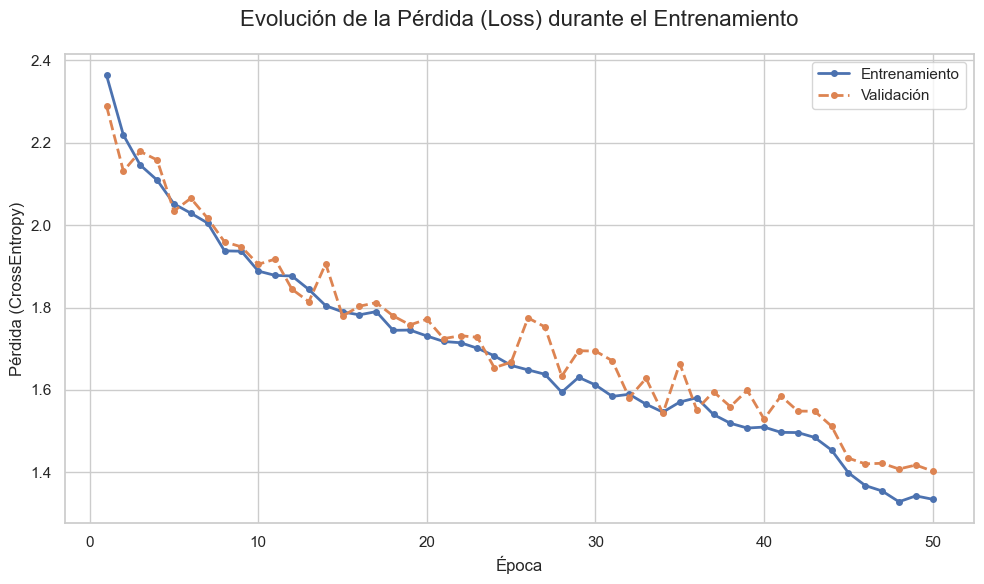

Gráfica guardada en: ./results/grafica_accuracy_custom.png


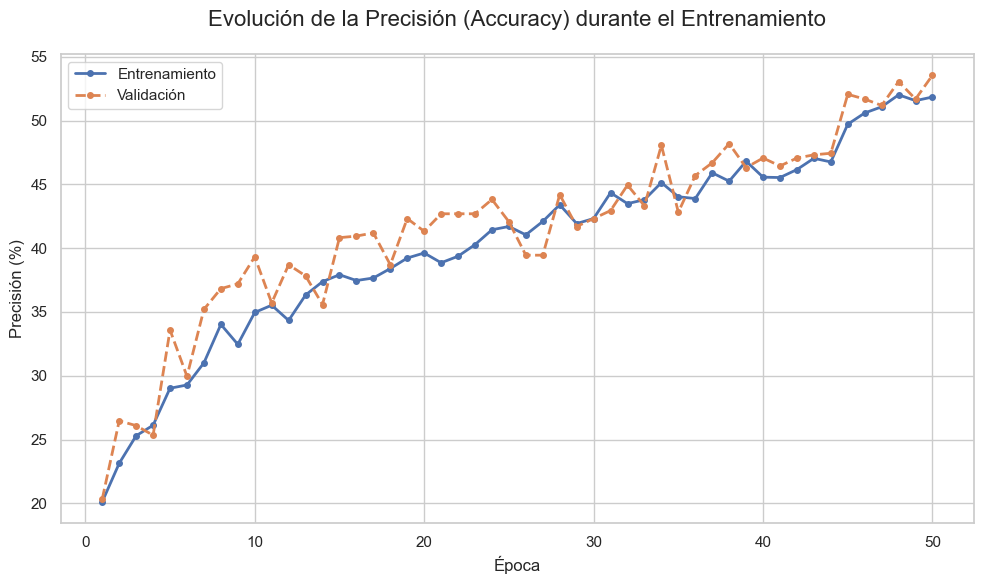

In [12]:
# Configuración
CSV_FILE = './results/training_history_custom.csv'
SAVE_DIR = './results' # Donde guardar las imágenes

# 1. Cargar datos
try:
    df = pd.read_csv(CSV_FILE)
    print(f"Datos cargados: {len(df)} épocas encontradas.")
except FileNotFoundError:
    print(f"Error: No se encuentra {CSV_FILE}")
    exit()

# 2. Configurar estilo de gráficas (Estilo Seaborn para que se vean profesionales)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# --- FUNCIÓN PARA DIBUJAR ---
def plot_metric(train_col, val_col, title, ylabel, filename):
    plt.figure(figsize=(10, 6))
    
    # Dibujar líneas
    plt.plot(df['epoch'], df[train_col], label='Entrenamiento', linewidth=2, marker='o', markersize=4)
    plt.plot(df['epoch'], df[val_col], label='Validación', linewidth=2, marker='o', markersize=4, linestyle='--')

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    
    # Guardar
    save_path = f"{SAVE_DIR}/{filename}"
    plt.savefig(save_path, dpi=300)
    print(f"Gráfica guardada en: {save_path}")
    plt.show()

# --- GENERAR GRÁFICAS ---

# 1. Gráfica de PÉRDIDA (Loss)
plot_metric(
    train_col='train_loss',
    val_col='val_loss',
    title='Evolución de la Pérdida (Loss) durante el Entrenamiento',
    ylabel='Pérdida (CrossEntropy)',
    filename='grafica_loss_custom.png'
)

# 2. Gráfica de PRECISIÓN (Accuracy)
plot_metric(
    train_col='train_acc',
    val_col='val_acc',
    title='Evolución de la Precisión (Accuracy) durante el Entrenamiento',
    ylabel='Precisión (%)',
    filename='grafica_accuracy_custom.png'
)

# EVALUA EL MODELO

Modelo SmartCNN (con GAP) creado.
✅ Pesos de 'best_model_custom.pth' cargados exitosamente.
Evaluando usando el conjunto de: test
Generando predicciones...


C:\Users\ivanp\AppData\Local\Temp\ipykernel_24412\4030271311.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ruta_modelo, map_location=d


 RESULTADOS DE LA EVALUACIÓN
              precision    recall  f1-score   support

           0       0.73      0.70      0.71        69
           1       0.55      0.75      0.64        56
           2       0.38      0.34      0.36        41
           3       0.42      0.25      0.31        20
           4       0.46      0.49      0.47        35
           5       0.72      0.96      0.82        45
           6       0.32      0.41      0.36        56
           7       0.52      0.49      0.51        47
           8       0.63      0.27      0.38        45
           9       0.51      0.42      0.46        43
          10       0.50      0.43      0.46        47
          11       0.38      0.58      0.46        55
          12       0.54      0.23      0.33        30
          13       0.95      0.81      0.87        47

    accuracy                           0.54       636
   macro avg       0.54      0.51      0.51       636
weighted avg       0.55      0.54      0.53       

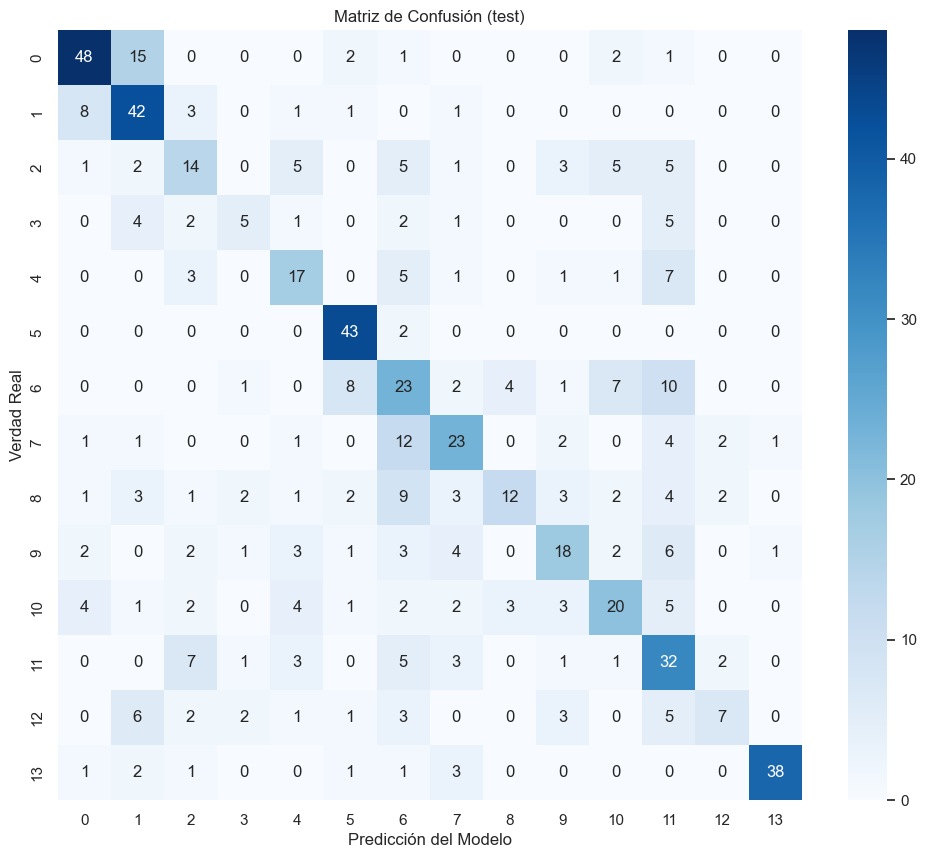

In [ ]:
# 1. Configuración inicial (Usa la misma función que definiste antes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(num_classes=14) 

# 2. Cargar los pesos aprendidos (best_model.pth)
ruta_modelo = './results/best_model_custom.pth'
if os.path.exists(ruta_modelo):
    model.load_state_dict(torch.load(ruta_modelo, map_location=device))
    print("✅ Pesos de 'best_model_custom.pth' cargados exitosamente.")
else:
    print("❌ Error: No encuentro 'best_model_custom.pth'. Asegúrate de que el archivo esté en la carpeta.")

model = model.to(device)
model.eval() # IMPORTANTE: Poner en modo evaluación

# 3. Elegir qué datos usar para la prueba
nombre_split = 'test' if 'test' in dataloaders else 'valid'
loader_prueba = dataloaders[nombre_split]
print(f"Evaluando usando el conjunto de: {nombre_split}")

# 4. Ejecutar predicciones
all_preds = []
all_labels = []

print("Generando predicciones...")
with torch.no_grad(): # Apagar el cálculo de gradientes para ir rápido
    for images, labels in loader_prueba:
        if -1 in labels: continue # Ignorar etiquetas inválidas si las hay
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 5. Calcular métricas
print("\n" + "="*30)
print(" RESULTADOS DE LA EVALUACIÓN")
print("="*30)

# Reporte numérico detallado
nombres_clases = [str(i) for i in range(14)] # Por defecto 0 al 13

print(classification_report(all_labels, all_preds, target_names=nombres_clases))

# 6. Generar y GUARDAR Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10)) # Hacer la figura un poco más grande

# Dibujar el mapa de calor
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Verdad Real')
plt.title(f'Matriz de Confusión ({nombre_split})')

nombre_matriz = './results/matriz_confusion_custom.png'
plt.savefig(nombre_matriz, dpi=300, bbox_inches='tight') 
print(f"Matriz de confusión guardada como: {nombre_matriz}")

plt.show()